# MNIST Probe Loss, Gradient Covariance, and Ghorbani-Style Hessian Density

This notebook trains an MLP on MNIST, then studies how the network can still move after training using the stop-gradient probe loss from *Understanding Plasticity in Neural Networks*:

`L_probe(theta) = || f_theta(X) - stop_gradient(f_theta0(X) + epsilon) ||^2`.

For the Hessian spectrum, it uses the implementation in `src.analysis.hessian_ghorbani`, based on Ghorbani, Krishnan, and Xiao's Hessian eigenvalue density procedure: Hessian-vector products plus stochastic Lanczos quadrature.

## Imports

In [1]:
import copy
import os
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import MNIST

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUTPUT_ROOT = ROOT / "outputs"
OUTPUT_ROOT.mkdir(exist_ok=True)
MPLCONFIGDIR = OUTPUT_ROOT / "matplotlib_cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

from src.models.mlp import MLP
from src.analysis.hessian_ghorbani import (
    gradient_covariance_for_probe_loss,
    hessian_spectral_density,
    make_probe_loss_closure,
    make_probe_targets,
    probe_adaptation_curve,
    probe_loss_from_targets,
)

## Reproducibility

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


## MNIST Dataset

The subset keeps the Hessian and covariance cells practical on a laptop. Increase `TRAIN_SUBSET_SIZE` or set it to `None` for full MNIST.

In [3]:
DATA_ROOT = ROOT / "data"
TRAIN_SUBSET_SIZE = 10000
BATCH_SIZE = 256

transform = transforms.ToTensor()
mnist = MNIST(
    root=str(DATA_ROOT),
    train=True,
    download=True,
    transform=transform,
)

train_dataset = mnist if TRAIN_SUBSET_SIZE is None else Subset(mnist, range(TRAIN_SUBSET_SIZE))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print("Dataset size:", len(train_dataset))

Dataset size: 10000


## Model

This uses the shared two-hidden-layer MLP implementation. Width 1024 matches the MNIST MLP scale used in the paper's optimizer-instability study; lower it if Hessian-vector products are too slow on CPU.

In [4]:
HIDDEN_DIM = 1024
model = MLP(input_shape=(1, 28, 28), hidden_dim=HIDDEN_DIM, num_actions=10).to(DEVICE)
initial_model = copy.deepcopy(model).to(DEVICE).eval()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

MLP(
  (fc1): Linear(in_features=784, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=1024, bias=True)
  (output): Linear(in_features=1024, out_features=10, bias=True)
  (ln1): Identity()
  (ln2): Identity()
  (relu1): ReLU()
  (relu2): ReLU()
)


## Accuracy Function

In [5]:
@torch.no_grad()
def compute_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        logits = model(x)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return correct / total

## Train on MNIST

In [6]:
EPOCHS = 10
loss_history = []
accuracy_history = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for x, y in train_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    acc = compute_accuracy(model, train_loader)
    loss_history.append(running_loss)
    accuracy_history.append(acc)

    print(f"Epoch {epoch + 1} | Loss={running_loss:.3f} | Acc={acc:.4f}")

trained_model = model.eval()

Epoch 1 | Loss=26.604 | Acc=0.9150
Epoch 2 | Loss=9.705 | Acc=0.9482
Epoch 3 | Loss=6.465 | Acc=0.9634
Epoch 4 | Loss=4.640 | Acc=0.9723
Epoch 5 | Loss=3.178 | Acc=0.9695
Epoch 6 | Loss=2.370 | Acc=0.9924
Epoch 7 | Loss=1.522 | Acc=0.9926
Epoch 8 | Loss=1.082 | Acc=0.9950
Epoch 9 | Loss=1.951 | Acc=0.9953
Epoch 10 | Loss=0.803 | Acc=0.9986


## Training Curves

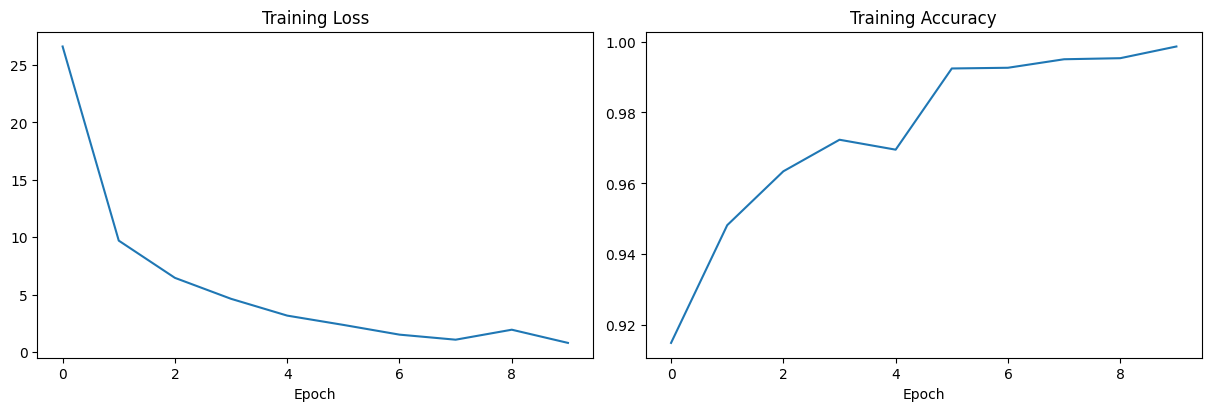

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(loss_history)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[1].plot(accuracy_history)
axes[1].set_title("Training Accuracy")
axes[1].set_xlabel("Epoch")
plt.show()

## Build Stop-Gradient Probe Targets

For each checkpoint, the target is detached once: `stop_gradient(f_theta0(X) + epsilon)`. The same `epsilon` is reused for the initial and trained checkpoints so the comparison is about the parameters, not different random targets.

In [8]:
PROBE_BATCH_SIZE = 128
probe_inputs, _ = next(iter(train_loader))
probe_inputs = probe_inputs[:PROBE_BATCH_SIZE].to(DEVICE)

initial_targets, shared_epsilon = make_probe_targets(initial_model, probe_inputs)
trained_targets, _ = make_probe_targets(trained_model, probe_inputs, epsilon=shared_epsilon)

initial_probe_loss = probe_loss_from_targets(initial_model, probe_inputs, initial_targets)
trained_probe_loss = probe_loss_from_targets(trained_model, probe_inputs, trained_targets)

print("Initial checkpoint probe loss:", float(initial_probe_loss.detach().cpu()))
print("Trained checkpoint probe loss:", float(trained_probe_loss.detach().cpu()))

Initial checkpoint probe loss: 1.027888536453247
Trained checkpoint probe loss: 1.027888536453247


## Probe Adaptation Curves

This trains copies of the initial and trained networks on their own probe targets. A slower or worse curve after MNIST training is one direct view of plasticity loss.

In [9]:
PROBE_OPT_STEPS = 200
PROBE_LR = 1e-3

initial_probe_model = copy.deepcopy(initial_model).to(DEVICE)
trained_probe_model = copy.deepcopy(trained_model).to(DEVICE)

initial_curve = probe_adaptation_curve(
    initial_probe_model,
    probe_inputs,
    initial_targets,
    steps=PROBE_OPT_STEPS,
    lr=PROBE_LR,
)
trained_curve = probe_adaptation_curve(
    trained_probe_model,
    probe_inputs,
    trained_targets,
    steps=PROBE_OPT_STEPS,
    lr=PROBE_LR,
)

print("Initial final probe loss:", initial_curve[-1])
print("Trained final probe loss:", trained_curve[-1])
print("Plasticity gap:", trained_curve[-1] - initial_curve[-1])

Initial final probe loss: 9.723585390020162e-05
Trained final probe loss: 0.0002601142623461783
Plasticity gap: 0.00016287840844597667


## Plot Probe Adaptation

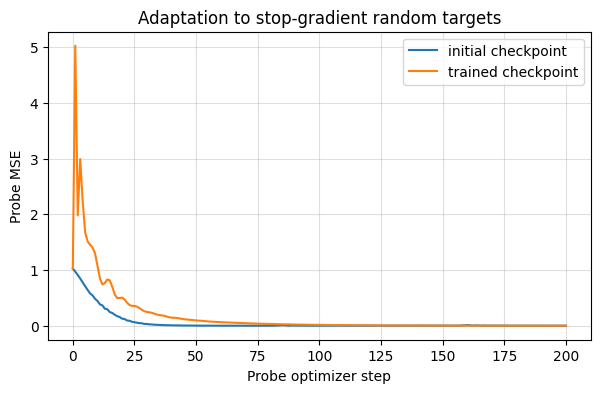

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(initial_curve, label="initial checkpoint")
plt.plot(trained_curve, label="trained checkpoint")
plt.xlabel("Probe optimizer step")
plt.ylabel("Probe MSE")
plt.title("Adaptation to stop-gradient random targets")
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

## Gradient Covariance on Probe Loss

This computes the cosine-similarity matrix of per-sample gradients of the probe loss, matching the geometric diagnostic used in the plasticity paper.

In [11]:
COVARIANCE_SAMPLES = 256
covariance = gradient_covariance_for_probe_loss(
    trained_model,
    probe_inputs,
    trained_targets,
    max_samples=COVARIANCE_SAMPLES,
)

print(covariance.shape)

torch.Size([128, 128])


## Gradient Covariance Heatmap

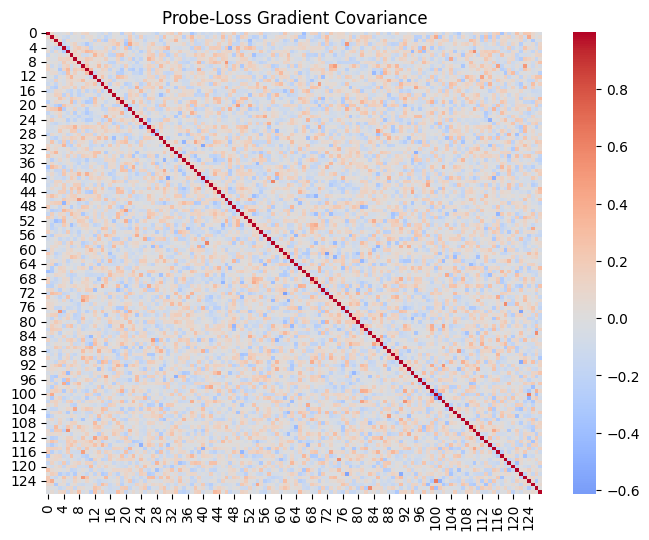

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(covariance.numpy(), cmap="coolwarm", center=0)
plt.title("Probe-Loss Gradient Covariance")
plt.show()

## Hessian Density with Stochastic Lanczos Quadrature

The cell below estimates the Hessian spectral density of the probe loss at the trained checkpoint. Increase `LANCZOS_STEPS` and `PROBE_VECTORS` for a smoother estimate; the defaults are intentionally notebook-friendly.

In [13]:
HESSIAN_BATCH_SIZE = 32
LANCZOS_STEPS = 20
PROBE_VECTORS = 1

hessian_inputs = probe_inputs[:HESSIAN_BATCH_SIZE]
hessian_targets = trained_targets[:HESSIAN_BATCH_SIZE]
loss_closure = make_probe_loss_closure(trained_model, hessian_inputs, hessian_targets)

trained_spectrum = hessian_spectral_density(
    trained_model,
    loss_closure,
    num_lanczos_steps=LANCZOS_STEPS,
    num_probe_vectors=PROBE_VECTORS,
    density_points=500,
    seed=SEED,
)

print("Raw quadrature nodes:", trained_spectrum.eigenvalues.shape)
print("Approx top eigenvalue:", float(trained_spectrum.eigenvalues.max()))

Raw quadrature nodes: (20,)
Approx top eigenvalue: 221.0477294921875


## Plot Hessian Density

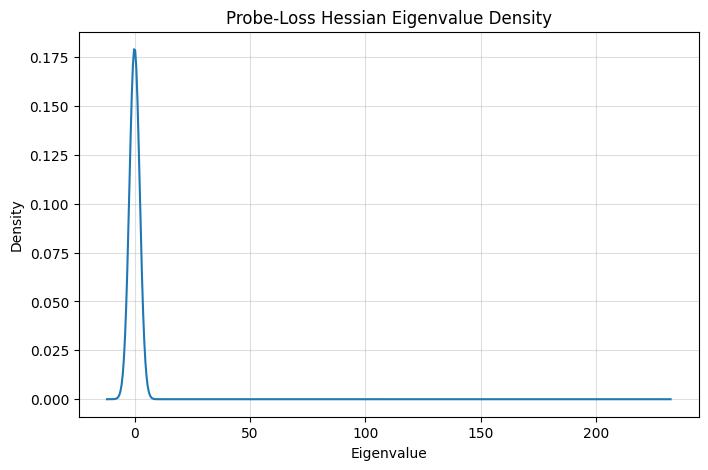

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(trained_spectrum.grid, trained_spectrum.density)
plt.xlabel("Eigenvalue")
plt.ylabel("Density")
plt.title("Probe-Loss Hessian Eigenvalue Density")
plt.grid(True, alpha=0.4)
plt.show()

## Optional: Initial vs Trained Hessian Density

This comparison is closer to the Ghorbani-style story of how spectra evolve during training. It costs another SLQ run, so it is separated from the default trained-checkpoint computation.

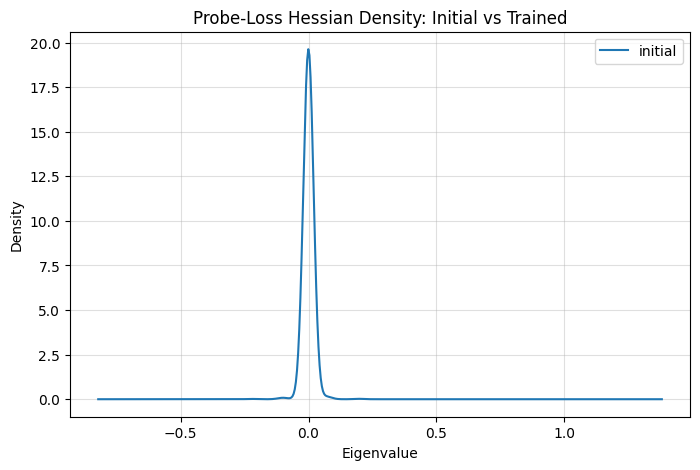

In [15]:
initial_loss_closure = make_probe_loss_closure(
    initial_model,
    hessian_inputs,
    initial_targets[:HESSIAN_BATCH_SIZE],
)
initial_spectrum = hessian_spectral_density(
    initial_model,
    initial_loss_closure,
    num_lanczos_steps=LANCZOS_STEPS,
    num_probe_vectors=PROBE_VECTORS,
    density_points=500,
    seed=SEED,
)

plt.figure(figsize=(8, 5))
plt.plot(initial_spectrum.grid, initial_spectrum.density, label="initial")
# plt.plot(trained_spectrum.grid, trained_spectrum.density, label="trained")
plt.xlabel("Eigenvalue")
plt.ylabel("Density")
plt.title("Probe-Loss Hessian Density: Initial vs Trained")
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

## Interpretation

The probe adaptation curve measures how quickly a checkpoint can move toward a fresh random target on the same inputs. The Hessian density and gradient covariance show the local geometry of that probe objective: large isolated eigenvalues, a broad positive tail, or structured gradient interference indicate that adaptation is occurring in a more constrained or sharper local landscape.